# Task 9 - Industrial Predictive Maintenance

## Project Overview

This project focuses on predictive maintenance using the AI4I 2020 Predictive Maintenance Dataset.

The goal is to use machine and sensor readings such as air temperature, process temperature, rotational speed, torque, and tool wear to predict whether a machine failure is likely to occur.

The dataset also contains indicators for different failure modes, including Tool Wear Failure (TWF), Heat Dissipation Failure (HDF), Power Failure (PWF), Overstrain Failure (OSF), and Random Failure (RNF).

The main classification target in this project is `Machine failure`, which represents whether any machine failure occurred.

A major requirement of this task is to focus on False Discovery Rate (FDR), since false alarms in an industrial environment may lead to unnecessary inspections, maintenance actions, and production interruptions.

The project therefore includes model comparison, cost-sensitive learning, feature engineering, anomaly detection, and prediction threshold tuning, with special attention to reducing false positive failure alerts.

A separate section is also included for the bonus tasks: assessing the feasibility of Time-to-Failure / Remaining Useful Life estimation and performing correlation analysis to identify potential sensor indicators of failure.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import os
import joblib

In [5]:
df = pd.read_csv("data/ai4i2020.csv")
display(df.head())

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (10000, 14)

Column names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Data types:
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [8]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Duplicate rows: 0


In [9]:
# Target and failure mode distribution

print("Machine Failure Distribution:")
print(df["Machine failure"].value_counts())
print("\nMachine Failure Percentage:")
print(df["Machine failure"].value_counts(normalize=True) * 100)

failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

print("\nFailure Mode Counts:")
for mode in failure_modes:
    print(f"{mode}: {df[mode].sum()}")

print("\nNumber of failure modes per row:")
failure_mode_count = df[failure_modes].sum(axis=1)
print(failure_mode_count.value_counts().sort_index())

Machine Failure Distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine Failure Percentage:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

Failure Mode Counts:
TWF: 46
HDF: 115
PWF: 95
OSF: 98
RNF: 19

Number of failure modes per row:
0    9652
1     324
2      23
3       1
Name: count, dtype: int64


## Failure Types and Target Definition

The AI4I 2020 dataset contains five failure-mode indicators:

- TWF: Tool Wear Failure
- HDF: Heat Dissipation Failure
- PWF: Power Failure
- OSF: Overstrain Failure
- RNF: Random Failure

These failure modes are not mutually exclusive. Some machine records contain more than one failure mode at the same time.

Therefore, forcing every failed machine into one single failure-type class would require an arbitrary rule and could misrepresent the original data.

For the main predictive maintenance model, `Machine failure` is used as the binary target because it represents whether a machine failure occurred.

The individual failure-mode columns are treated as separate target labels for failure-type analysis and are never used as input features.

This prevents target leakage, since the failure-mode indicators directly describe the failure event itself.

In [10]:
# Compare sensor averages between normal and failed machines

sensor_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

failure_means = df.groupby("Machine failure")[sensor_features].mean().T

display(failure_means)

Machine failure,0,1
Air temperature [K],299.973999,300.886431
Process temperature [K],309.995570,310.290265
Rotational speed [rpm],1540.260014,1496.486726
Torque [Nm],39.629655,50.168142
Tool wear [min],106.693717,143.781711


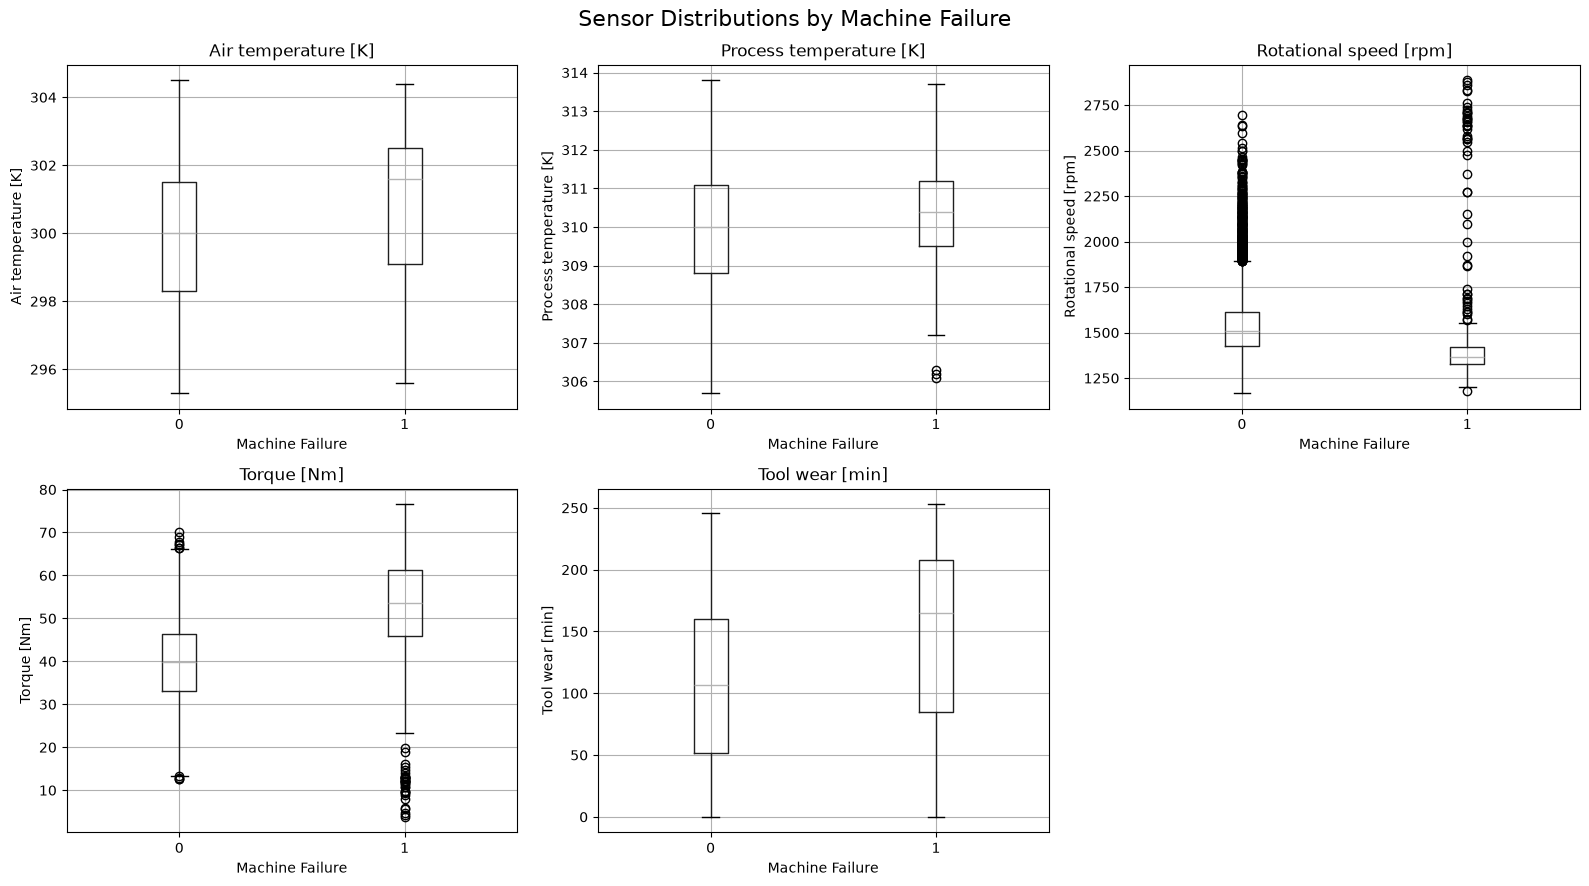

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feature in enumerate(sensor_features):
    df.boxplot(
        column=feature,
        by="Machine failure",
        ax=axes[i]
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel("Machine Failure")
    axes[i].set_ylabel(feature)

axes[-1].axis("off")

plt.suptitle("Sensor Distributions by Machine Failure", fontsize=16)
plt.tight_layout()
plt.show()

## Bonus: Correlation Analysis and Potential Lead Indicators

Correlation analysis is used to examine the association between sensor readings and machine failure.

The analysis focuses on variables such as temperature, torque, rotational speed, and tool wear.

However, correlation alone does not establish causation or prove that a sensor is a temporal lead indicator.

The available AI4I 2020 CSV does not contain an explicit timestamp or a temporal sequence of sensor readings leading up to each failure. Therefore, this analysis can identify sensors with stronger cross-sectional associations with failure, but it cannot prove that a sensor changes before the failure occurs.

The results are therefore interpreted as potential indicators rather than confirmed temporal lead indicators.

In [12]:
correlation_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

correlations = (
    df[correlation_features + ["Machine failure"]]
    .corr()["Machine failure"]
    .drop("Machine failure")
    .sort_values(key=abs, ascending=False)
)

print("Correlation with Machine Failure:")
display(correlations.to_frame("Correlation"))

Correlation with Machine Failure:


,Correlation
Torque [Nm],0.191321
Tool wear [min],0.105448
Air temperature [K],0.082556
Rotational speed [rpm],-0.044188
Process temperature [K],0.035946


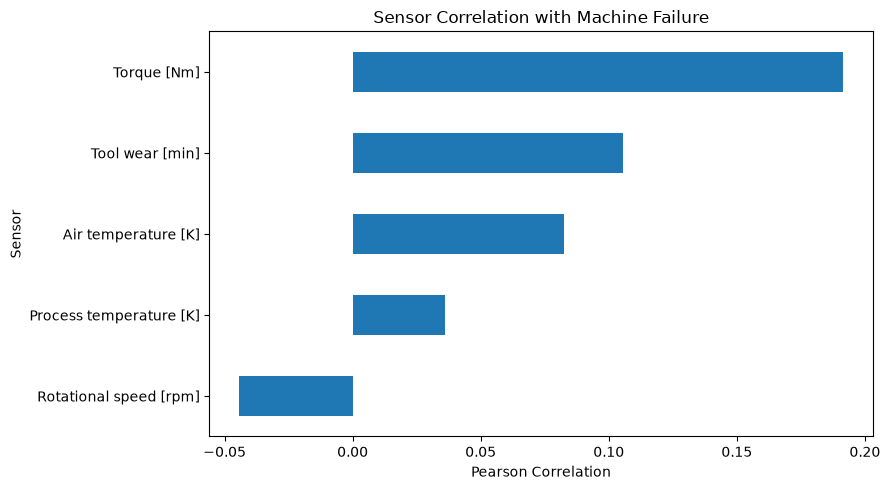

In [13]:
plt.figure(figsize=(9, 5))

correlations.sort_values().plot(kind="barh")

plt.title("Sensor Correlation with Machine Failure")
plt.xlabel("Pearson Correlation")
plt.ylabel("Sensor")

plt.tight_layout()
plt.show()

## Bonus: Requested Sensor Lead Indicator Analysis

The task specifically asks to compare Temperature, Torque, and Speed as potential lead indicators of machine failure.

The available AI4I 2020 dataset does not contain timestamps or sequential sensor readings before failure. Therefore, a temporal lead-lag relationship cannot be established from this dataset.

Instead, the available cross-sectional correlations are used to compare the strength of association between the requested sensor groups and machine failure.

Among the requested sensor groups, Torque shows the strongest direct association with machine failure.

This result should be interpreted as an association rather than a confirmed temporal lead indicator, because the dataset does not contain timestamped sequential sensor readings.


In [45]:
requested_sensor_analysis = pd.Series({
    "Temperature": df[
        ["Air temperature [K]", "Process temperature [K]"]
    ].corrwith(df["Machine failure"]).abs().mean(),

    "Torque": abs(
        df["Torque [Nm]"].corr(df["Machine failure"])
    ),

    "Speed": abs(
        df["Rotational speed [rpm]"].corr(
            df["Machine failure"]
        )
    )
}).sort_values(ascending=False)

print("Requested Sensor Association with Machine Failure:")
display(
    requested_sensor_analysis.to_frame(
        "Mean Absolute Correlation"
    )
)

Requested Sensor Association with Machine Failure:


,Mean Absolute Correlation
Torque,0.191321
Temperature,0.059251
Speed,0.044188


## Feature Engineering

The original sensor readings provide useful information, but machine failures can also depend on interactions between multiple measurements.

To capture these relationships, additional features are created from the available sensor readings:

- `Temperature Difference [K]`: Process temperature minus air temperature.
- `Torque-Speed Interaction`: Torque multiplied by rotational speed, representing a combined mechanical load indicator.
- `Tool Wear-Torque Interaction`: Tool wear multiplied by torque, capturing the interaction between accumulated tool wear and mechanical load.

These features are calculated only from input variables and do not use any failure labels, so they do not introduce target leakage.

In [14]:
df["Temperature Difference [K]"] = (
    df["Process temperature [K]"] - df["Air temperature [K]"]
)

df["Torque-Speed Interaction"] = (
    df["Torque [Nm]"] * df["Rotational speed [rpm]"]
)

df["Tool Wear-Torque Interaction"] = (
    df["Tool wear [min]"] * df["Torque [Nm]"]
)

engineered_features = [
    "Temperature Difference [K]",
    "Torque-Speed Interaction",
    "Tool Wear-Torque Interaction"
]

print("Engineered features:")
display(df[engineered_features].head())

Engineered features:


,Temperature Difference [K],Torque-Speed Interaction,Tool Wear-Torque Interaction
0,10.5,66382.8,0.0
1,10.5,65190.4,138.9
2,10.4,74001.2,247.0
3,10.4,56603.5,276.5
4,10.5,56320.0,360.0


## Bonus: Time-to-Failure / Remaining Useful Life

A Time-to-Failure or Remaining Useful Life (RUL) regression model requires temporal information, such as timestamps, machine operating histories, failure times, or an explicit RUL target.

The AI4I 2020 dataset is provided as a multivariate dataset with sequentially generated observations, but the available CSV does not contain an explicit timestamp, failure-time target, or Remaining Useful Life (RUL) label.

Therefore, a true Time-to-Failure/RUL regression model cannot be trained reliably from the available columns without introducing an unsupported target definition.

Creating an artificial failure-time or RUL target from the available columns would introduce an unsupported assumption and would not represent actual remaining useful life.

This limitation is documented as part of the bonus requirement rather than using a fabricated regression target.

In [46]:
time_rul_columns = [
    col for col in df.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "time",
            "date",
            "timestamp",
            "rul",
            "remaining",
            "failure time"
        ]
    )
]

print("Potential time/RUL columns:")
print(time_rul_columns)

if not time_rul_columns:
    print(
        "\nNo timestamp, failure-time, or RUL target is available."
    )
    print(
        "A valid Time-to-Failure regression model cannot "
        "be trained without a temporal target."
    )

Potential time/RUL columns:
[]

No timestamp, failure-time, or RUL target is available.
A valid Time-to-Failure regression model cannot be trained without a temporal target.


## Train, Validation, and Test Split

The data is divided into training, validation, and test sets using a stratified split.

- 70% of the data is used for training.
- 15% is used for validation and model selection.
- 15% is reserved as an untouched test set for final evaluation.

Stratification is used because machine failure is highly imbalanced, with failures representing only a small percentage of the dataset.

The identifier columns `UDI` and `Product ID` are excluded from the predictive features.

The overall target `Machine failure` is separated from the input features.

The individual failure-mode columns (`TWF`, `HDF`, `PWF`, `OSF`, and `RNF`) are also excluded from the predictive features because they directly describe failure events and would cause target leakage.

In [16]:
target = "Machine failure"

failure_mode_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]

drop_columns = [
    "UDI",
    "Product ID",
    target
] + failure_mode_columns

X = df.drop(columns=drop_columns)
y = df[target]

print("Feature columns:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Feature columns:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature Difference [K]', 'Torque-Speed Interaction', 'Tool Wear-Torque Interaction']

Feature shape: (10000, 9)
Target shape: (10000,)


In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nFailure rate:")
print("Train:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

Train: (7000, 9) (7000,)
Validation: (1500, 9) (1500,)
Test: (1500, 9) (1500,)

Failure rate:
Train: 0.033857142857142856
Validation: 0.034
Test: 0.034


## Anomaly Detection

Isolation Forest is used as an unsupervised anomaly detection technique to identify unusual machine operating conditions.

Unlike the supervised classifiers, the Isolation Forest is trained without using the `Machine failure` target.

The model is fitted using the training sensor data only. Numerical sensor and engineered features are standardized before fitting the anomaly detector.

The anomaly detector is evaluated on the validation and test sets by comparing its anomaly predictions with the actual machine failure labels.

This analysis is used as a complementary anomaly-detection approach and is not treated as the final failure classifier.

In [18]:
anomaly_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference [K]",
    "Torque-Speed Interaction",
    "Tool Wear-Torque Interaction"
]

anomaly_scaler = StandardScaler()

X_train_anomaly = anomaly_scaler.fit_transform(
    X_train[anomaly_features]
)

X_val_anomaly = anomaly_scaler.transform(
    X_val[anomaly_features]
)

X_test_anomaly = anomaly_scaler.transform(
    X_test[anomaly_features]
)

print("Anomaly detection features:", len(anomaly_features))
print("Training anomaly data shape:", X_train_anomaly.shape)

Anomaly detection features: 8
Training anomaly data shape: (7000, 8)


In [19]:
isolation_forest = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42
)

isolation_forest.fit(X_train_anomaly)

print("Isolation Forest trained successfully.")

Isolation Forest trained successfully.


In [20]:
# Generate anomaly predictions

val_anomaly_raw = isolation_forest.predict(X_val_anomaly)
test_anomaly_raw = isolation_forest.predict(X_test_anomaly)

# Isolation Forest returns:
#  1  -> normal
# -1  -> anomaly

y_val_anomaly = (val_anomaly_raw == -1).astype(int)
y_test_anomaly = (test_anomaly_raw == -1).astype(int)

print("Validation anomalies:", y_val_anomaly.sum())
print("Test anomalies:", y_test_anomaly.sum())

Validation anomalies: 304
Test anomalies: 304


In [21]:
def calculate_fdr(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    if tp + fp == 0:
        return 0.0

    return fp / (tp + fp)


val_anomaly_fdr = calculate_fdr(y_val, y_val_anomaly)
test_anomaly_fdr = calculate_fdr(y_test, y_test_anomaly)

print("Validation Anomaly Detection")
print("Precision:", precision_score(y_val, y_val_anomaly, zero_division=0))
print("Recall:", recall_score(y_val, y_val_anomaly, zero_division=0))
print("F1:", f1_score(y_val, y_val_anomaly, zero_division=0))
print("FDR:", val_anomaly_fdr)

print("\nTest Anomaly Detection")
print("Precision:", precision_score(y_test, y_test_anomaly, zero_division=0))
print("Recall:", recall_score(y_test, y_test_anomaly, zero_division=0))
print("F1:", f1_score(y_test, y_test_anomaly, zero_division=0))
print("FDR:", test_anomaly_fdr)

Validation Anomaly Detection
Precision: 0.12171052631578948
Recall: 0.7254901960784313
F1: 0.2084507042253521
FDR: 0.8782894736842105

Test Anomaly Detection
Precision: 0.14802631578947367
Recall: 0.8823529411764706
F1: 0.2535211267605634
FDR: 0.8519736842105263


### Anomaly Detection Results

The Isolation Forest successfully identified unusual machine operating conditions and detected a substantial portion of the actual failure cases.

However, the anomaly detector produced a high False Discovery Rate (FDR):

- Validation FDR: approximately 87.83%
- Test FDR: approximately 85.20%

This means that many observations identified as anomalies were not actual machine failures.

The result highlights an important distinction between anomaly detection and supervised failure prediction: an unusual operating condition does not necessarily mean that a machine failure will occur.

Therefore, Isolation Forest is treated as a complementary anomaly-detection technique rather than the final production failure classifier. The supervised classification models will be optimized separately with special attention to reducing false positive failure alerts.

## Failure Type Classification - Multi-Label Approach

The dataset contains multiple failure-mode indicators rather than one mutually exclusive failure-type column.

Because a machine can have more than one failure mode simultaneously, the failure-type prediction problem is formulated as a multi-label classification problem.

Each failure mode is treated as an independent binary target:

- TWF: Tool Wear Failure
- HDF: Heat Dissipation Failure
- PWF: Power Failure
- OSF: Overstrain Failure
- RNF: Random Failure

The predictive features remain the sensor and engineered features only. The failure-mode columns are used exclusively as target labels and are not provided as model inputs.

In [22]:
failure_mode_targets = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

y_modes = df[failure_mode_targets].copy()

# Use the same indices as the train/validation/test split
y_modes_train = y_modes.loc[X_train.index]
y_modes_val = y_modes.loc[X_val.index]
y_modes_test = y_modes.loc[X_test.index]

print("Training failure-mode targets:")
display(y_modes_train.sum().to_frame("Failure Count"))

print("\nValidation failure-mode targets:")
display(y_modes_val.sum().to_frame("Failure Count"))

print("\nTest failure-mode targets:")
display(y_modes_test.sum().to_frame("Failure Count"))

Training failure-mode targets:


,Failure Count
TWF,33
HDF,73
PWF,72
OSF,71
RNF,13



Validation failure-mode targets:


,Failure Count
TWF,5
HDF,24
PWF,10
OSF,12
RNF,4



Test failure-mode targets:


,Failure Count
TWF,8
HDF,18
PWF,13
OSF,15
RNF,2


## Multi-Label Failure Type Model

A Random Forest classifier is used inside a `MultiOutputClassifier` to predict the five failure modes independently.

Each output represents one failure mode, allowing a machine to be assigned more than one predicted failure type.

The model uses only sensor readings and engineered features. Failure-mode columns are excluded from the input data to prevent target leakage.

Because the failure modes are highly imbalanced, class weighting is used to give more importance to the rare failure cases during training.

In [23]:
categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference [K]",
    "Torque-Speed Interaction",
    "Tool Wear-Torque Interaction"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [25]:
failure_type_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            MultiOutputClassifier(
                RandomForestClassifier(
                    n_estimators=300,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1
                )
            )
        )
    ]
)

failure_type_model.fit(
    X_train,
    y_modes_train
)

print("Multi-label failure type model trained successfully.")

Multi-label failure type model trained successfully.


In [26]:
y_modes_val_pred = failure_type_model.predict(X_val)

y_modes_val_pred = pd.DataFrame(
    y_modes_val_pred,
    columns=failure_mode_targets,
    index=X_val.index
)

display(y_modes_val_pred.head())

,TWF,HDF,PWF,OSF,RNF
5637,0,0,0,0,0
2838,0,0,0,0,0
3597,0,0,0,0,0
3571,0,0,0,0,0
8389,0,0,0,0,0


In [27]:
mode_results = []

for mode in failure_mode_targets:
    y_true = y_modes_val[mode]
    y_pred = y_modes_val_pred[mode]

    fdr = calculate_fdr(y_true, y_pred)

    mode_results.append({
        "Failure Mode": mode,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "FDR": fdr
    })

mode_results_df = pd.DataFrame(mode_results)

display(mode_results_df)

,Failure Mode,Accuracy,Precision,Recall,F1,FDR
0,TWF,0.996667,0.000000,0.000000,0.000000,0.000000
1,HDF,0.995333,0.869565,0.833333,0.851064,0.130435
2,PWF,0.999333,1.000000,0.900000,0.947368,0.000000
3,OSF,1.000000,1.000000,1.000000,1.000000,0.000000
4,RNF,0.997333,0.000000,0.000000,0.000000,0.000000


### Multi-Label Failure Type Results

The multi-label model shows different performance across the five failure modes.

HDF achieved 86.96% precision, 83.33% recall, and 13.04% FDR on the validation set.

PWF achieved 100% precision, 90% recall, and 0% FDR, while OSF achieved 100% precision, 100% recall, and 0% FDR on the validation set.

For TWF and RNF, the model did not produce any positive predictions, resulting in 0% precision, recall, and F1-score. The reported FDR of 0% for these cases should not be interpreted as perfect performance because no positive alerts were generated.

RNF contains only a small number of positive examples, including only 4 positive cases in the validation set. Therefore, its metrics are unstable and should be interpreted cautiously.

Overall, the results demonstrate that failure-mode prediction performance varies substantially by failure type, especially for rare failure modes.

In [28]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

y_val_logistic = logistic_model.predict(X_val)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [29]:
logistic_metrics = {
    "Accuracy": accuracy_score(y_val, y_val_logistic),
    "Precision": precision_score(y_val, y_val_logistic, zero_division=0),
    "Recall": recall_score(y_val, y_val_logistic, zero_division=0),
    "F1": f1_score(y_val, y_val_logistic, zero_division=0),
    "FDR": calculate_fdr(y_val, y_val_logistic)
}

print("Logistic Regression Validation Results:")
for metric, value in logistic_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_logistic))

Logistic Regression Validation Results:
Accuracy: 0.8620
Precision: 0.1695
Recall: 0.7843
F1: 0.2787
FDR: 0.8305

Confusion Matrix:
[[1253  196]
 [  11   40]]


## Random Forest Baseline

A Random Forest classifier is trained as a nonlinear baseline model.

Random Forest can capture nonlinear relationships and interactions between sensor measurements that may not be represented well by a linear model.

The model is evaluated on the validation set using Accuracy, Precision, Recall, F1-score, and False Discovery Rate (FDR).

Since FDR is the main industrial constraint, the Random Forest results will be compared with the Logistic Regression baseline primarily based on its false-alarm behavior.

In [30]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

y_val_rf = random_forest_model.predict(X_val)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [31]:
rf_metrics = {
    "Accuracy": accuracy_score(y_val, y_val_rf),
    "Precision": precision_score(y_val, y_val_rf, zero_division=0),
    "Recall": recall_score(y_val, y_val_rf, zero_division=0),
    "F1": f1_score(y_val, y_val_rf, zero_division=0),
    "FDR": calculate_fdr(y_val, y_val_rf)
}

print("Random Forest Validation Results:")
for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_rf))

Random Forest Validation Results:
Accuracy: 0.9927
Precision: 0.9348
Recall: 0.8431
F1: 0.8866
FDR: 0.0652

Confusion Matrix:
[[1446    3]
 [   8   43]]


## Baseline Model Comparison

Two baseline classifiers were evaluated on the validation set.

Logistic Regression achieved 86.20% accuracy, 16.95% precision, 78.43% recall, and an FDR of 83.05%.

Random Forest achieved 99.27% accuracy, 93.48% precision, 84.31% recall, and an FDR of 6.52%.

The Random Forest substantially reduced false discovery compared with Logistic Regression while also achieving higher precision, recall, and F1-score.

The results demonstrate that a nonlinear ensemble model is better suited to the relationships between the machine sensor measurements in this dataset.

However, Random Forest is still treated as a baseline at this stage. The next step applies cost-sensitive learning to explicitly investigate the effect of assigning a higher cost to false-positive failure alerts.

In [32]:
cost_sensitive_results = []

negative_class_weights = [1, 2, 3, 5]

for negative_weight in negative_class_weights:

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=300,
                    class_weight={
                        0: negative_weight,
                        1: 1
                    },
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    cost_sensitive_results.append({
        "Negative Class Weight": negative_weight,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1": f1_score(y_val, y_pred, zero_division=0),
        "FDR": calculate_fdr(y_val, y_pred)
    })

cost_sensitive_results_df = pd.DataFrame(cost_sensitive_results)

display(cost_sensitive_results_df)

,Negative Class Weight,Accuracy,Precision,Recall,F1,FDR
0,1,0.993333,0.93617,0.862745,0.897959,0.06383
1,2,0.992000,0.97561,0.784314,0.869565,0.02439
2,3,0.991333,1.00000,0.745098,0.853933,0.00000
3,5,0.991333,1.00000,0.745098,0.853933,0.00000


## Cost-Sensitive Learning Results

Cost-sensitive Random Forest models were evaluated by increasing the weight assigned to the negative class.

Increasing the negative-class weight makes the classifier more conservative when predicting machine failure. This directly reduces false-positive failure alerts, which is important in an industrial environment where unnecessary maintenance actions can interrupt production.

With a negative-class weight of 1, the model achieved 93.62% precision, 86.27% recall, and 6.38% FDR.

Increasing the weight to 2 improved precision to 97.56% and reduced FDR to 2.44%, but recall decreased to 78.43%.

Weights of 3 and 5 achieved 0% FDR on the validation set, but recall decreased further to 74.51%.

This demonstrates the trade-off between minimizing false alarms and maintaining failure detection capability.

For the later model-selection and threshold-tuning stage, a project-level criterion of Recall >= 50% will be used so that FDR reduction does not come at the cost of ignoring most real failures.

In [34]:
xgb_cost_results = []

negative_sample_weights = [1, 2, 3]

# Transform the data once using the existing preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

for negative_weight in negative_sample_weights:

    sample_weights = np.where(
        y_train == 0,
        negative_weight,
        1.0
    )

    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(
        X_train_processed,
        y_train,
        sample_weight=sample_weights
    )

    y_val_xgb = xgb_model.predict(X_val_processed)

    xgb_cost_results.append({
        "Negative Sample Weight": negative_weight,
        "Accuracy": accuracy_score(y_val, y_val_xgb),
        "Precision": precision_score(y_val, y_val_xgb, zero_division=0),
        "Recall": recall_score(y_val, y_val_xgb, zero_division=0),
        "F1": f1_score(y_val, y_val_xgb, zero_division=0),
        "FDR": calculate_fdr(y_val, y_val_xgb)
    })

xgb_cost_results_df = pd.DataFrame(xgb_cost_results)

display(xgb_cost_results_df)

,Negative Sample Weight,Accuracy,Precision,Recall,F1,FDR
0,1,0.988000,0.851064,0.784314,0.816327,0.148936
1,2,0.988667,0.869565,0.784314,0.824742,0.130435
2,3,0.985333,0.837209,0.705882,0.765957,0.162791


In [35]:
rf_cost_sensitive = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight={
                    0: 2,
                    1: 1
                },
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_cost_sensitive.fit(X_train, y_train)

print("Cost-sensitive Random Forest trained successfully.")

Cost-sensitive Random Forest trained successfully.


In [36]:
y_val_rf_proba = rf_cost_sensitive.predict_proba(X_val)[:, 1]

print("Validation probability range:")
print("Minimum:", y_val_rf_proba.min())
print("Maximum:", y_val_rf_proba.max())

print("\nFirst 10 probabilities:")
print(y_val_rf_proba[:10])

Validation probability range:
Minimum: 0.0
Maximum: 0.9566666666666667

First 10 probabilities:
[0.         0.         0.         0.         0.         0.00333333
 0.         0.         0.         0.00333333]


In [37]:
threshold_results = []

thresholds = np.arange(0.10, 0.91, 0.05)

for threshold in thresholds:

    y_pred_threshold = (
        y_val_rf_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(
            y_val,
            y_pred_threshold
        ),
        "Precision": precision_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "FDR": calculate_fdr(
            y_val,
            y_pred_threshold
        ),
        "False Positives": confusion_matrix(
            y_val,
            y_pred_threshold
        ).ravel()[1],
        "False Negatives": confusion_matrix(
            y_val,
            y_pred_threshold
        ).ravel()[2]
    })

threshold_results_df = pd.DataFrame(threshold_results)

display(threshold_results_df)

,Threshold,Accuracy,Precision,Recall,F1,FDR,False Positives,False Negatives
0,0.10,0.979333,0.647059,0.862745,0.739496,0.352941,24,7
1,0.15,0.988000,0.800000,0.862745,0.830189,0.200000,11,7
2,0.20,0.990000,0.846154,0.862745,0.854369,0.153846,8,7
3,0.25,0.990667,0.862745,0.862745,0.862745,0.137255,7,7
4,0.30,0.990667,0.862745,0.862745,0.862745,0.137255,7,7
5,0.35,0.990667,0.877551,0.843137,0.860000,0.122449,6,8
6,0.40,0.992000,0.914894,0.843137,0.877551,0.085106,4,8
7,0.45,0.992000,0.933333,0.823529,0.875000,0.066667,3,9
8,0.50,0.992000,0.975610,0.784314,0.869565,0.024390,1,11
9,0.55,0.992000,1.000000,0.764706,0.866667,0.000000,0,12


## Threshold Tuning and Industrial Operating Point

The default classification threshold of 0.50 was tuned using the validation set to better satisfy the industrial requirement of minimizing false-positive failure alerts.

The project uses Recall >= 50% as a selection criterion to prevent excessive reduction in failure detection while minimizing FDR.

Several thresholds achieved 0% FDR on the validation set. A threshold of 0.55 was selected because it achieved:

- 100% precision
- 76.47% recall
- 86.67% F1-score
- 0% FDR
- 0 false positives
- 12 false negatives

Higher thresholds also produced 0% FDR but progressively reduced recall.

Therefore, 0.55 was selected as the operating threshold for the final evaluation.

In [38]:
selected_threshold = 0.55

y_test_rf_proba = rf_cost_sensitive.predict_proba(X_test)[:, 1]

y_test_final = (
    y_test_rf_proba >= selected_threshold
).astype(int)

final_test_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_final),
    "Precision": precision_score(
        y_test,
        y_test_final,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_test_final,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        y_test_final,
        zero_division=0
    ),
    "FDR": calculate_fdr(
        y_test,
        y_test_final
    )
}

print("Final Test Results:")
for metric, value in final_test_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_final))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_final,
        target_names=["No Failure", "Failure"],
        zero_division=0
    )
)

Final Test Results:
Accuracy: 0.9907
Precision: 1.0000
Recall: 0.7255
F1: 0.8409
FDR: 0.0000

Confusion Matrix:
[[1449    0]
 [  14   37]]

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      1.00      1.00      1449
     Failure       1.00      0.73      0.84        51

    accuracy                           0.99      1500
   macro avg       1.00      0.86      0.92      1500
weighted avg       0.99      0.99      0.99      1500



## Final Model Evaluation

The final model is a cost-sensitive Random Forest classifier with a negative-class weight of 2 and a classification threshold of 0.55.

The threshold was selected using the validation set, while the test set remained untouched until the final evaluation.

On the unseen test set, the final model achieved:

- Accuracy: 99.07%
- Precision: 100%
- Recall: 72.55%
- F1-score: 84.09%
- FDR: 0%

The confusion matrix contained 1,449 true negatives, 37 true positives, 14 false negatives, and 0 false positives.

The 0% FDR means that none of the failure alerts generated on the test set were false alarms. This directly satisfies the main industrial constraint of minimizing unnecessary failure alerts.

However, the model did not detect all actual failures, with a recall of 72.55%. Therefore, the model prioritizes reliable failure alerts over maximizing the number of detected failures.

The final results should be interpreted as a cost-sensitive operating point rather than as evidence that the model can detect every failure event.

## Feature Importance

Feature importance is used to identify which input features contributed most to the predictions of the final Random Forest model.

The analysis uses the fitted cost-sensitive Random Forest selected for the final evaluation.

Feature importance shows how useful each feature was for the trained model, but it does not prove that a feature directly causes machine failure.

The feature importance results are also compared with the earlier correlation analysis. Among the original sensor measurements, Torque showed the strongest direct correlation with machine failure, while the Random Forest assigned high importance to Torque and to engineered features that combine Torque with other sensor measurements.

In [39]:
# Extract the fitted Random Forest and preprocessing steps
rf_estimator = rf_cost_sensitive.named_steps["classifier"]
fitted_preprocessor = rf_cost_sensitive.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Get Random Forest feature importances
feature_importances = rf_estimator.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Feature Importance:")
display(feature_importance_df)

Feature Importance:


,Feature,Importance
0,num__Torque-Speed Interaction,0.214783
1,num__Tool Wear-Torque Interaction,0.192229
2,num__Rotational speed [rpm],0.159759
3,num__Torque [Nm],0.131963
4,num__Temperature Difference [K],0.105035
5,num__Tool wear [min],0.058404
6,num__Process temperature [K],0.043754
7,num__Air temperature [K],0.038693
8,cat__Type_L,0.031079
9,cat__Type_M,0.018754


### Feature Importance Results

The feature importance analysis shows that the engineered interaction features contributed substantially to the final Random Forest predictions.

The most important feature was `Torque-Speed Interaction` with an importance of 21.48%, followed by `Tool Wear-Torque Interaction` with 19.22%.

Other important features included Rotational speed (15.98%), Torque (13.20%), and Temperature Difference (10.50%).

This result supports the usefulness of feature engineering because the interaction features ranked among the most important predictors.

The feature importance results also complement the earlier correlation analysis. Among the original sensor measurements, Torque showed the strongest direct correlation with machine failure, while the Random Forest assigned high importance to Torque and to engineered features that combine Torque with other sensor measurements.

Feature importance describes how useful features were to the trained model and does not establish a causal relationship between a sensor measurement and machine failure.

In [41]:

# Make sure the artifacts directory exists
os.makedirs("artifacts", exist_ok=True)

# Store the final model and all information needed for inference
final_artifact = {
    "model": rf_cost_sensitive,
    "threshold": selected_threshold,
    "feature_columns": X.columns.tolist(),
    "target": target,
    "engineered_features": engineered_features,
    "model_type": "Cost-sensitive Random Forest",
    "negative_class_weight": 2,
    "selection_criterion": "Recall >= 50% with minimum FDR"
}

artifact_path = "artifacts/predictive_maintenance_model.pkl"

joblib.dump(
    final_artifact,
    artifact_path
)

print(f"Final model artifact saved to: {artifact_path}")
print(f"Artifact size: {os.path.getsize(artifact_path) / 1024:.2f} KB")

Final model artifact saved to: artifacts/predictive_maintenance_model.pkl
Artifact size: 3478.94 KB


## Final Model Artifact Verification

The trained predictive maintenance model was saved as a reusable artifact in `artifacts/predictive_maintenance_model.pkl`.

The saved artifact contains the trained cost-sensitive Random Forest, the selected classification threshold, the feature columns, the target definition, and the engineered features.

The artifact was reloaded successfully and tested on a small sample to verify that it can be used for inference after being saved.

This verification is separate from the final test-set evaluation. The final model performance remains based on the untouched test-set results reported above.

In [43]:
loaded_artifact = joblib.load(
    "artifacts/predictive_maintenance_model.pkl"
)

loaded_model = loaded_artifact["model"]
loaded_threshold = loaded_artifact["threshold"]

print("Artifact loaded successfully.")
print("Model type:", loaded_artifact["model_type"])
print("Threshold:", loaded_threshold)
print("Number of features:", len(loaded_artifact["feature_columns"]))

sample_X = X_test.head(5)

sample_probabilities = loaded_model.predict_proba(sample_X)[:, 1]

sample_predictions = (
    sample_probabilities >= loaded_threshold
).astype(int)

print("\nSample failure probabilities:")
print(sample_probabilities)

print("\nSample predictions:")
print(sample_predictions)

Artifact loaded successfully.
Model type: Cost-sensitive Random Forest
Threshold: 0.55
Number of features: 9

Sample failure probabilities:
[0. 0. 0. 0. 0.]

Sample predictions:
[0 0 0 0 0]
